In [2]:
ls

sample_data/


In [3]:
# skip this cell if you already downloaded the data
!git clone https://github.com/Belaleatsbanana/dl.git
%cd dl
!python get_data.py

Cloning into 'dl'...
remote: Enumerating objects: 115, done.
remote: Counting objects: 100% (115/115), done.
remote: Compressing objects: 100% (74/74), done.
remote: Total 115 (delta 58), reused 98 (delta 41), pack-reused 0 (from 0)
Receiving objects: 100% (115/115), 91.29 KiB | 1.94 MiB/s, done.
Resolving deltas: 100% (58/58), done.
/content/dl
Loading dataset from Hugging Face...
`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'ethz/food101' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
README.md: 16.4kB [00:00, 10.5MB/s]
data/train-00000-of-00008.parquet: 100% 490M/490M [00:02<00:00, 173MB/s] 
data/train-00001-of-00008.parquet: 100% 464M/464M [00:01<00:00, 256MB/s] 
data/train-00002-of-00008.parquet: 100% 472M/472M [00:02<00:00, 235MB/s] 
data/train-00003-of-00008.parquet: 100% 464M/464M [

In [5]:
!python main.py --model_to_run resnext50_local

[2026-04-01 03:07:11,981 resnext50_local] (main.py 21): INFO Dataset loaded: 3750 train images, 1250 validation images
[2026-04-01 03:07:11,981 resnext50_local] (main.py 23): INFO Creating model: resnext50_local
[2026-04-01 03:07:12,229 resnext50_local] (main.py 58): INFO Start training
[2026-04-01 03:07:27,274 resnext50_local] (main.py 124): INFO Epoch: [0][0/59] lr 0.000001 loss 1.8503 acc 29.69%
[2026-04-01 03:07:33,141 resnext50_local] (main.py 124): INFO Epoch: [0][20/59] lr 0.000001 loss 1.9744 acc 21.73%
[2026-04-01 03:07:40,330 resnext50_local] (main.py 124): INFO Epoch: [0][40/59] lr 0.000001 loss 1.9545 acc 20.43%
[2026-04-01 03:08:00,683 resnext50_local] (main.py 67): INFO [Epoch 0]: Train Loss: 1.9427, Train Acc: 19.84%, Val Loss: 1.6968, Val Acc: 20.00%, F1: 0.0667, Precision: 0.0400, Recall: 0.2000
[2026-04-01 03:08:00,683 resnext50_local] (main.py 78): INFO Best performance updated at epoch 0 with accuracy: 20.00%
[2026-04-01 03:08:00,683 resnext50_local] (main.py 80): I

In [ ]:
!python main.py --model_to_run deit_tiny

In [ ]:
!python main.py --model_to_run as_mlp_tiny

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from models import get_model_config

def load_results(output_dir='outputs'):
    metrics_dfs = []
    cms = {}
    best_metrics = []
    
    if not os.path.exists(output_dir):
        return None, None, None
        
    files = os.listdir(output_dir)
    model_names = set([f.replace('_metrics.csv', '') for f in files if f.endswith('_metrics.csv')])
    
    for name in model_names:
        # Load metrics
        metrics_path = os.path.join(output_dir, f'{name}_metrics.csv')
        df = pd.read_csv(metrics_path)
        
        # Get TAG
        config = get_model_config(name)
        tag = config['MODEL']['TAG']
        df['model_name'] = name
        df['tag'] = tag
        metrics_dfs.append(df)
        
        # Get best metrics
        best_epoch_idx = df['val_acc'].idxmax()
        best_row = df.loc[best_epoch_idx].copy()
        best_metrics.append(best_row)
        
        # Load confusion matrix
        cm_path = os.path.join(output_dir, f'{name}_confusion_matrix.npy')
        if os.path.exists(cm_path):
            cms[name] = np.load(cm_path)
            
    all_metrics = pd.concat(metrics_dfs, ignore_index=True)
    best_metrics_df = pd.DataFrame(best_metrics)
    
    
    return all_metrics, best_metrics_df, cms

all_metrics, best_metrics_df, cms = load_results()
if best_metrics_df is not None:
    display(best_metrics_df.sort_values(by='val_acc', ascending=False))

,epoch,train_loss,train_acc,val_loss,val_acc,val_f1,val_precision,val_recall,model_name,tag
84,84,0.825906,78.64,0.328823,91.12,0.911042,0.912564,0.9112,resnext50_local,CNN


## Learning Curves

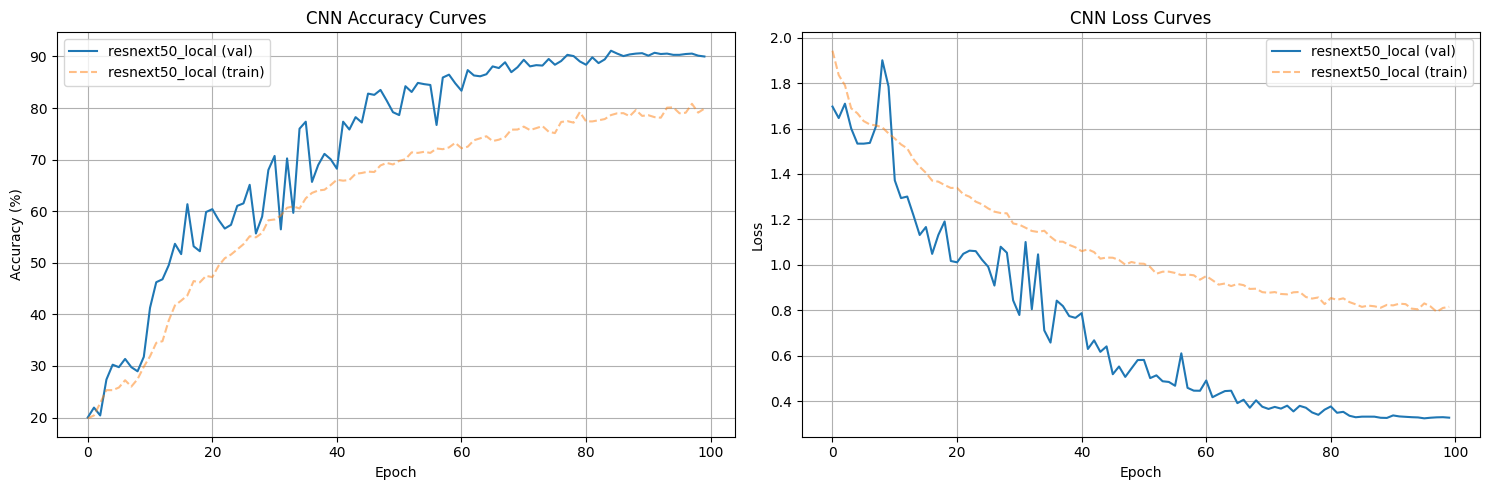

In [7]:
def plot_learning_curves(df, tag):
    tag_df = df[df['tag'] == tag]
    if tag_df.empty:
        print(f"No results for {tag}")
        return
    
    plt.figure(figsize=(15, 5))
    
    # Accuracy plot
    plt.subplot(1, 2, 1)
    for name in tag_df['model_name'].unique():
        model_df = tag_df[tag_df['model_name'] == name]
        plt.plot(model_df['epoch'], model_df['val_acc'], label=f'{name} (val)')
        plt.plot(model_df['epoch'], model_df['train_acc'], '--', alpha=0.5, label=f'{name} (train)')
    plt.title(f'{tag} Accuracy Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    
    # Loss plot
    plt.subplot(1, 2, 2)
    for name in tag_df['model_name'].unique():
        model_df = tag_df[tag_df['model_name'] == name]
        plt.plot(model_df['epoch'], model_df['val_loss'], label=f'{name} (val)')
        plt.plot(model_df['epoch'], model_df['train_loss'], '--', alpha=0.5, label=f'{name} (train)')
    plt.title(f'{tag} Loss Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_learning_curves(all_metrics, 'CNN')

In [ ]:
plot_learning_curves(all_metrics, 'MLP')

In [ ]:
plot_learning_curves(all_metrics, 'Transformer')

## Confusion Matrices Comparison

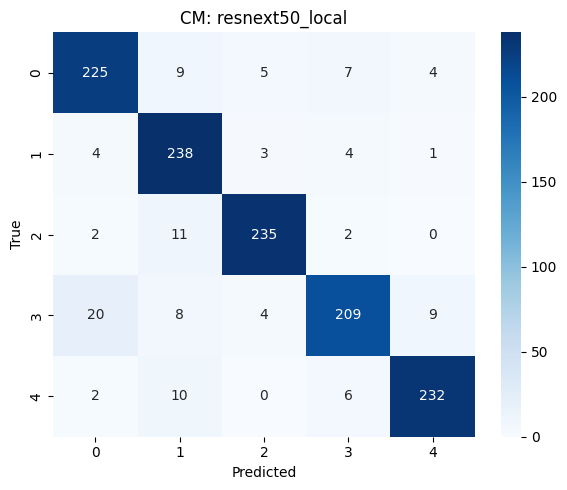

In [8]:
def plot_cms(best_df, cms_dict, tag):
    tag_models = best_df[best_df['tag'] == tag]['model_name'].tolist()
    if not tag_models:
        print(f"No confusion matrices for {tag}")
        return
        
    n_models = len(tag_models)
    plt.figure(figsize=(6*n_models, 5))
    
    for i, name in enumerate(tag_models):
        if name in cms_dict:
            plt.subplot(1, n_models, i+1)
            sns.heatmap(cms_dict[name], annot=True, fmt='d', cmap='Blues')
            plt.title(f'CM: {name}')
            plt.xlabel('Predicted')
            plt.ylabel('True')
            
    plt.tight_layout()
    plt.show()

plot_cms(best_metrics_df, cms, 'CNN')

In [ ]:
plot_cms(best_metrics_df, cms, 'MLP')

In [ ]:
plot_cms(best_metrics_df, cms, 'Transformer')

## Final Comparison: Best CNN vs Best MLP vs Best Transformer

,tag,model_name,val_acc,val_f1,val_precision,val_recall
84,CNN,resnext50_local,91.12,0.911042,0.912564,0.9112


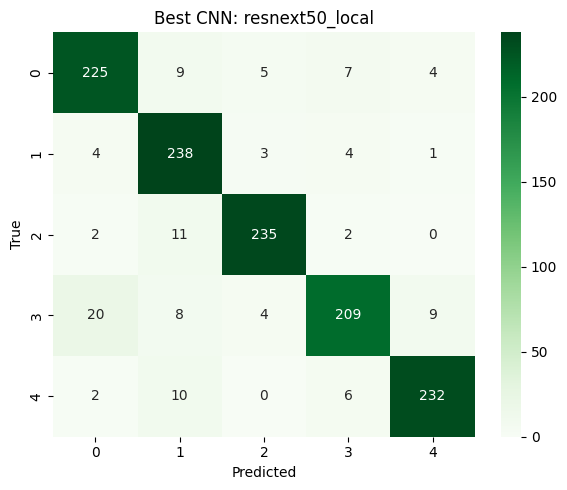

In [9]:
def final_comparison(best_df, cms_dict):
    # Get best model for each tag
    final_best = best_df.sort_values('val_acc', ascending=False).groupby('tag').head(1)
    display(final_best[['tag', 'model_name', 'val_acc', 'val_f1', 'val_precision', 'val_recall']])
    
    # Plot their CMs
    best_models = final_best['model_name'].tolist()
    plt.figure(figsize=(6*len(best_models), 5))
    for i, name in enumerate(best_models):
        if name in cms_dict:
            plt.subplot(1, len(best_models), i+1)
            sns.heatmap(cms_dict[name], annot=True, fmt='d', cmap='Greens')
            tag = final_best[final_best['model_name'] == name]['tag'].values[0]
            plt.title(f'Best {tag}: {name}')
            plt.xlabel('Predicted')
            plt.ylabel('True')
    plt.tight_layout()
    plt.show()

if best_metrics_df is not None:
    final_comparison(best_metrics_df, cms)

In [ ]:
import shutil
shutil.make_archive('outputs', 'zip', 'outputs')
print("Outputs zipped to outputs.zip")

# print size of outputs.zip


Outputs zipped to outputs.zip


In [11]:
print(f"Size of outputs.zip: {os.path.getsize('outputs.zip') / (1024 * 1024):.2f} MB")

Size of outputs.zip: 0.02 MB
